# Visualisations

This notebook contains all three visualisations for the AWAS streaming pipeline.

| Visualisation | Section | Data source |
|---|---|---|
| Folium static map | Task 2.2.1 | MongoDB (`violations` + `cameras` collections) |
| Static Matplotlib dashboard | Task 2.2.2 | MongoDB (`violations` collection) |
| HD live Matplotlib dashboard | Task 2.2.2 | JSON sink files (incremental, live) |

> The Folium map and static Matplotlib dashboard query MongoDB directly and are intended to be run once (or a few times) after the streaming pipeline has completed.


In [ ]:
# Setup: load camera metadata and MongoDB connection
import pandas as pd
import json
from pathlib import Path
from pymongo import MongoClient

MONGO_URI = "mongodb://mongodb:27017/"
MONGO_DB  = "fit3182_a2"

def get_mongo_db():
    """Return a pymongo Database handle. Caller is responsible for closing the client."""
    client = MongoClient(MONGO_URI)
    return client, client[MONGO_DB]

camera_pd = (
    pd.read_csv(Path('..') / 'data' / 'camera.csv')
    [['camera_id', 'position', 'speed_limit', 'latitude', 'longitude']]
    .sort_values('camera_id')
    .reset_index(drop=True)
)
camera_pd['camera_id'] = camera_pd['camera_id'].astype(int)

print(f'Loaded {len(camera_pd)} cameras from camera.csv')
print(camera_pd)


Loaded 3 cameras from camera.csv
   camera_id  position  speed_limit  latitude   longitude
0          1     152.5          110  2.157731  102.660100
1          2     153.5          110  2.162419  102.652455
2          3     154.5           90  2.167353  102.644914


## Folium Static Map

Reads camera statistics directly from MongoDB (the `violations` collection in `fit3182_a2`).
Run once (or a few times) after the streaming pipeline has finished to get an accurate snapshot.

**Reason for using JSON:**
- Our mongodb doesn't store information about cars that do not have any violations, and due to this reaosn we need somewhere else to store this information (local JSON sink file)
- The reason we don't just make a new mongodb collection for this information or add new fields to existing collections is because that it isn't something really needed or something core to the functionality of the system. If this visualisation were to be scaled up to be made into something bigger, then we can consider storing this data in mongodb instead of a local JSON file.


In [2]:
import folium
from IPython.display import display, clear_output

CAMERA_STATS_PATH = Path('..') / 'outputs' / 'camera_stats.json'

def load_camera_stats():
    if CAMERA_STATS_PATH.exists():
        with open(CAMERA_STATS_PATH, 'r', encoding='utf-8') as f:
            return json.load(f)
    return {
        'car_count': {},
        'speed_sum': {},
        'violations_instant': {},
        'violations_average': {},
    }

def build_camera_map():
    stats = load_camera_stats()
    center_lat = float(camera_pd['latitude'].mean())
    center_lon = float(camera_pd['longitude'].mean())
    fmap = folium.Map(location=[center_lat, center_lon], zoom_start=14)
    for _, row in camera_pd.iterrows():
        camera_id = str(int(row['camera_id']))
        car_count = stats['car_count'].get(camera_id, 0)
        instant_count = stats['violations_instant'].get(camera_id, 0)
        average_count = stats['violations_average'].get(camera_id, 0)
        total_violations = instant_count + average_count
        speed_sum = stats['speed_sum'].get(camera_id, 0.0)
        avg_speed = speed_sum / car_count if car_count else 0.0
        violation_pct = (total_violations / car_count * 100) if car_count else 0.0

        if violation_pct >= 50:
            severity = 'Critical'
            severity_color = '#e74c3c'
        elif violation_pct >= 30:
            severity = 'High'
            severity_color = '#e67e22'
        elif violation_pct >= 15:
            severity = 'Medium'
            severity_color = '#f1c40f'
        else:
            severity = 'Low'
            severity_color = '#2ecc71'

        bar_pct = max(0.0, min(100.0, violation_pct))

        popup_html = f"""
<div style="font-family: 'Arial', sans-serif; font-size: 13px; line-height: 1.3;">
  <div style="display: flex; align-items: center; justify-content: space-between; gap: 8px;">
    <div><b>Camera {camera_id}</b></div>
    <div style="background: {severity_color}; color: #fff; padding: 2px 8px; border-radius: 10px; font-size: 11px;">
      {severity}
    </div>
  </div>
  <div style="margin-top: 6px;">
    <div style="font-size: 12px; color: #555;">Violation rate</div>
    <div style="background: #eee; border-radius: 6px; overflow: hidden; height: 10px;">
      <div style="width: {bar_pct:.1f}%; background: {severity_color}; height: 10px;"></div>
    </div>
    <div style="font-size: 12px; color: #555; margin-top: 2px;">
      {violation_pct:.2f}% of cars
    </div>
  </div>
  <details style="margin-top: 8px;">
    <summary style="cursor: pointer;">Details</summary>
    <ul style="margin: 6px 0 0 16px; padding: 0;">
      <li>Cars passed: {car_count}</li>
      <li>Instant violations: {instant_count}</li>
      <li>Average speed violations: {average_count}</li>
      <li>Total violations: {total_violations}</li>
      <li>Average speed: {avg_speed:.2f} km/h</li>
    </ul>
  </details>
</div>
"""

        popup_content = folium.Html(popup_html, script=True)

        folium.Marker(
            location=[float(row['latitude']), float(row['longitude'])],
            popup=folium.Popup(
                popup_content,
                max_width=320,
                sticky=True,
                lazy=True
            ),
            tooltip=f'Camera {camera_id} (click for details)'
        ).add_to(fmap)
    return fmap

def render_camera_map():
    clear_output(wait=True)
    display(build_camera_map())

print('Folium map functions defined.')


Folium map functions defined.


In [3]:
# Re-run this cell to refresh the map during the simulation.
render_camera_map()


## Live Matplotlib Charts

Run this cell after the streaming queries are started. Interrupt the cell to stop the live updates.

**Two types of visualisations:**
- Static dashboard showcasing aggregated statistics and interesting points
- Live dynamic plot showcasing the number of violations every 10 minutes

**Data source reasoning:**
- Static dashboard: Gets data from mongodb due to the fact that the data will not be queried as often, so even if we use mongodb the stress on the backend mongodb server will not be too high at any given time since we won't be querying that much.
- Live plot: Gets data from a local JSON file sink. This is due to the fact that having to query for data every second will have heavy workload if done via mongodb (given that the data volume scales up, for our current dataset it will still be fine). Due to this, it is a lot faster to just query the data/values from a local JSON file rather than mongodb.

**Static plot choice reasoning:**
- Total Violations By Camera: This way, we can know which cameras have the most violations and as such can station traffic officers near the camera.
- Speed Distribution of Violations: So we can see which camera's violators on average have a higher speed. That way, we can take more precautions to slow down the cars near this camera to make it not as dangerous for other drives near this camera.
- Number of Unique Offending Vehicles per Camera: Same reasoning as Total Violations By Camera, but with this one we can then see whether the same cars keep violating the same camera multiple times.
- Top 10 Repeat Offenders: So that we can see which cars keep violating the speed limit.

**Other notable things:**
- Assumptions: streaming is running, JSON sinks are append only, clocks are consistent enough for per minute bucketing, missing fields are treated as 0 or skipped.
- Limitations: live plot is eventually consistent and lagging; JSON file growth is unbounded; MongoDB aggregation is snapshot only and can be stale while streams run.
- Interpretation guidance: counts are per violation event (not per vehicle), average speed violations are attributed to the exit camera, and live plot uses a sliding window, not full history.
- Data quality notes: malformed JSON lines are skipped. If a camera file is absent the live chart waits.
- Reproducibility: re-running cells can reset local JSON stats and change the live plot’s baseline.


In [ ]:
%matplotlib inline

import json
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import matplotlib.dates as mdates
from pathlib import Path
from datetime import datetime
from IPython.display import clear_output

# File paths (must match write_json_per_batch destinations)
BASE_DIR = Path("..")

INSTANT_PATHS = {
    "Camera A": BASE_DIR / "outputs" / "instant_violations_json" / "camera_a" / "results.json",
    "Camera B": BASE_DIR / "outputs" / "instant_violations_json" / "camera_b" / "results.json",
    "Camera C": BASE_DIR / "outputs" / "instant_violations_json" / "camera_c" / "results.json",
}

AVG_PATHS = {
    "Segment A-B": BASE_DIR / "outputs" / "average_violations_json" / "camera_ab" / "results.json",
    "Segment B-C": BASE_DIR / "outputs" / "average_violations_json" / "camera_bc" / "results.json",
}

# Config
REFRESH_SECONDS = 5   # wall-clock seconds between redraws
WINDOW_MINUTES  = 60  # sliding window width for per-minute + scatter panels
TOP_N_OFFENDERS = 10  # how many plates to show in the lollipop chart

# Shared colour constants 
_C_INST  = "#c0392b"   # instantaneous
_C_AVG   = "#8e44ad"   # average speed


def _load_jsonl(path):
    """Read a JSON-Lines file into a list of dicts; return [] if missing/corrupt."""
    p = Path(path)
    if not p.exists():
        return []
    rows = []
    with open(p, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line:
                try:
                    rows.append(json.loads(line))
                except json.JSONDecodeError:
                    pass
    return rows

def fetch_all_violations():
    """
    Load all violation JSON files and return a unified DataFrame.

    Columns produced:
      car_plate, violation_type (INSTANTANEOUS / AVERAGE),
      speed_reading, speed_limit, plot_time (datetime64),
      camera_id_start, camera_id_end
    """
    rows = []

    # Instantaneous
    for label, path in INSTANT_PATHS.items():
        for rec in _load_jsonl(path):
            rows.append({
                "car_plate":       rec.get("car_plate", ""),
                "violation_type":  "INSTANTANEOUS",
                "speed_reading":   float(rec.get("speed_recorded", rec.get("speed_reading", 0))),
                "speed_limit":     float(rec.get("speed_limit", 0)),
                "plot_time":       rec.get("event_time"),
                "camera_id_start": int(rec.get("camera_id", 0)),
                "camera_id_end":   int(rec.get("camera_id", 0)),
            })

    # Average speed
    for label, path in AVG_PATHS.items():
        for rec in _load_jsonl(path):
            rows.append({
                "car_plate":       rec.get("car_plate", ""),
                "violation_type":  "AVERAGE",
                "speed_reading":   float(rec.get("average_speed", rec.get("avg_speed", 0))),
                "speed_limit":     float(rec.get("speed_limit", 0)),
                "plot_time":       rec.get("exit_time", rec.get("entry_time")),
                "camera_id_start": int(rec.get("start_camera_id", 0)),
                "camera_id_end":   int(rec.get("end_camera_id", 0)),
            })

    if not rows:
        return pd.DataFrame()

    df = pd.DataFrame(rows)
    df["plot_time"] = pd.to_datetime(df["plot_time"], utc=True).dt.tz_localize(None)
    return df.sort_values("plot_time").reset_index(drop=True)


def window_slice(df, minutes=WINDOW_MINUTES):
    """Return only the rows within the most-recent *minutes* of event time."""
    if df.empty:
        return df.copy()
    end   = df["plot_time"].max()
    start = end - pd.Timedelta(minutes=minutes)
    return df[(df["plot_time"] >= start) & (df["plot_time"] <= end)].copy()



def _get_speed_limit(cam_id):
    """Look up speed limit for a camera from camera_pd."""
    try:
        row = camera_pd[camera_pd["camera_id"].astype(int) == cam_id]
        return float(row["speed_limit"].values[0]) if len(row) else 60.0
    except Exception:
        return 60.0


# Chart 1: Total violations by camera (grouped bar: instant vs average)
def _draw_violations_by_camera(ax, df):
    """
    Grouped bar chart: total instantaneous and average-speed violations
    broken down by camera. Gives an at-a-glance view of which camera has
    the highest enforcement load and which violation type dominates there.

    Interesting-point annotations:
      - Shaded background highlights the busiest camera column.
      - Arrow callout on the tallest bar marks the most active camera and
        its total violation count.
      - Per-bar value labels for quick reading.
    """
    ax.set_facecolor("#fafafa")
    ax.set_title("Total Violations by Camera", fontsize=9)

    if df.empty:
        ax.text(0.5, 0.5, "Waiting for streaming data…",
                ha="center", va="center", transform=ax.transAxes,
                color="#aaa", fontsize=11)
        ax.set_xlabel("Camera")
        ax.set_ylabel("Total violations")
        return

    cam_ids = sorted(df["camera_id_end"].unique())
    x       = np.arange(len(cam_ids))
    width   = 0.38

    inst_counts = [
        int((df[(df["camera_id_end"] == c) & (df["violation_type"] == "INSTANTANEOUS")]).shape[0])
        for c in cam_ids
    ]
    avg_counts = [
        int((df[(df["camera_id_end"] == c) & (df["violation_type"] == "AVERAGE")]).shape[0])
        for c in cam_ids
    ]
    totals = [i + a for i, a in zip(inst_counts, avg_counts)]

    #  Shade background of busiest camera column ─
    busiest_idx = int(np.argmax(totals))
    ax.axvspan(busiest_idx - 0.5, busiest_idx + 0.5, color="#fde8e8", alpha=0.55, zorder=0)

    bars_i = ax.bar(x - width / 2, inst_counts, width=width, color=_C_INST,
                    alpha=0.88, label=f"Instantaneous ({sum(inst_counts)})")
    bars_a = ax.bar(x + width / 2, avg_counts,  width=width, color=_C_AVG,
                    alpha=0.88, label=f"Average speed ({sum(avg_counts)})")

    #  Value labels on each bar 
    for bar in list(bars_i) + list(bars_a):
        h = bar.get_height()
        if h > 0:
            ax.text(bar.get_x() + bar.get_width() / 2, h + 0.3,
                    str(int(h)), ha="center", va="bottom", fontsize=8, fontweight="bold")

    #  Arrow callout on tallest bar of the busiest camera 
    peak_total = totals[busiest_idx]
    peak_cam   = cam_ids[busiest_idx]
    peak_bar_h = max(inst_counts[busiest_idx], avg_counts[busiest_idx])
    ax.annotate(
        f"Busiest: Camera {peak_cam}, {peak_total} total violations",
        xy=(busiest_idx - width / 2, inst_counts[busiest_idx]),
        xytext=(busiest_idx + 0.6, peak_bar_h * 1.15),
        fontsize=8, color="#922b21", fontweight="bold",
        arrowprops=dict(arrowstyle="->", color="#922b21", lw=1.0),
    )

    ax.set_xticks(x)
    ax.set_xticklabels([f"Camera {c}" for c in cam_ids], fontsize=9)
    ax.set_ylabel("Total violations", fontsize=8)
    ax.legend(loc="upper right", fontsize=8)
    ax.grid(True, axis="y", alpha=0.3, linestyle="--")
    ax.spines[["top", "right"]].set_visible(False)
    ax.set_ylim(0, max(totals, default=1) * 1.35 + 1)


# Chart 2: Speed distribution per camera (histogram + percentile annotations)
def _draw_speed_distribution(ax, df):
    """
    Overlapping histograms of recorded violation speeds, one series per camera.
    Vertical dashed lines mark each camera's speed limit.

    Interesting-point annotations:
      - Dynamically computed p75, p90, p95 percentile lines across all
        violations, with labelled callouts on the x-axis.
      - Shaded region between p90 and p95 highlights the extreme tail of
        offenders — the most egregious speeders.
      - Arrow callout marks the single highest recorded speed.
    """
    ax.set_facecolor("#fafafa")
    ax.set_title("Speed Distribution of Violations (all-time)", fontsize=9)

    if df.empty:
        ax.text(0.5, 0.5, "Waiting for streaming data…",
                ha="center", va="center", transform=ax.transAxes,
                color="#aaa", fontsize=11)
        ax.set_xlabel("Speed (km/h)")
        ax.set_ylabel("Count")
        return

    cam_ids = sorted(df["camera_id_end"].unique())
    palette = ["#2980b9", "#27ae60", "#e67e22", "#8e44ad"]

    for idx, cam_id in enumerate(cam_ids):
        speeds = df[df["camera_id_end"] == cam_id]["speed_reading"].dropna()
        if speeds.empty:
            continue
        color = palette[idx % len(palette)]
        ax.hist(speeds, bins=20, alpha=0.50, color=color,
                label=f"Camera {cam_id} (n={len(speeds)})", edgecolor="white", linewidth=0.4)
        limit = _get_speed_limit(cam_id)
        ax.axvline(limit, color=color, linestyle="--", linewidth=1.4,
                   label=f"Cam {cam_id} limit ({int(limit)} km/h)")

    #  Dynamically computed cross-camera percentiles ─
    all_speeds = df["speed_reading"].dropna()
    if len(all_speeds) >= 10:
        p75, p90, p95 = np.percentile(all_speeds, [75, 90, 95])

        # Shaded tail region: p90 → p95 (extreme offenders)
        ax.axvspan(p90, p95, color="#f9e79f", alpha=0.45, zorder=0,
                   label="p90–p95 extreme tail")

        y_top = ax.get_ylim()[1]

        for pval, plabel, pcolor in [
            (p75, "p75", "#117a65"),
            (p90, "p90", "#b7950b"),
            (p95, "p95", "#922b21"),
        ]:
            ax.axvline(pval, color=pcolor, linestyle=":", linewidth=1.5, zorder=3)
            ax.text(pval + 0.4, y_top * 0.92,
                    f"{plabel}, {pval:.0f} km/h",
                    color=pcolor, fontsize=7, fontweight="bold", va="top")

        #  Arrow callout on the single fastest recorded speed 
        max_speed = all_speeds.max()
        ax.annotate(
            f"Max: {max_speed:.0f} km/h",
            xy=(max_speed, 0),
            xytext=(max_speed - (max_speed * 0.08), y_top * 0.55),
            fontsize=8, color="#922b21", fontweight="bold",
            arrowprops=dict(arrowstyle="->", color="#922b21", lw=1.0),
        )

    ax.set_xlabel("Speed (km/h)", fontsize=8)
    ax.set_ylabel("Violations", fontsize=8)
    ax.legend(loc="upper left", fontsize=7, ncol=1)
    ax.grid(True, axis="y", alpha=0.25, linestyle="--")
    ax.spines[["top", "right"]].set_visible(False)


# Chart 3: Unique offending vehicles & avg excess speed per camera
def _draw_unique_offenders_by_camera(ax, df):
    """
    Horizontal bar chart: number of distinct car plates that triggered at
    least one violation at each camera. Annotates the average speed excess
    (recorded speed − speed limit) per camera as an inline label.

    Interesting-point annotations:
      - Shaded background row for the camera with the highest avg speed excess
        (most severe, not just most frequent).
      - Arrow callout identifies that camera with its excess value.
      - p75 percentile line across unique-vehicle counts to contextualise
        which cameras are above-average offender hotspots.
    """
    ax.set_facecolor("#fafafa")
    ax.set_title("Unique Offending Vehicles per Camera", fontsize=9)

    if df.empty:
        ax.text(0.5, 0.5, "Waiting for streaming data…",
                ha="center", va="center", transform=ax.transAxes,
                color="#aaa", fontsize=11)
        ax.set_xlabel("Unique vehicles")
        return

    cam_ids = sorted(df["camera_id_end"].unique())
    unique_counts = []
    avg_excess    = []
    for cam_id in cam_ids:
        sub = df[df["camera_id_end"] == cam_id]
        unique_counts.append(sub["car_plate"].nunique())
        excess = (sub["speed_reading"] - sub["speed_limit"]).clip(lower=0)
        avg_excess.append(excess.mean() if not excess.empty else 0.0)

    y = np.arange(len(cam_ids))

    #  Shade the row with the highest average speed excess ─
    severe_idx = int(np.argmax(avg_excess))
    ax.axhspan(severe_idx - 0.4, severe_idx + 0.4, color="#fde8e8", alpha=0.55, zorder=0)

    palette = ["#2980b9", "#27ae60", "#e67e22", "#8e44ad"]
    colors = [palette[idx % len(palette)] for idx in range(len(cam_ids))]
    bars = ax.barh(y, unique_counts, color=colors, alpha=0.88, height=0.5)

    #  Inline labels: count + avg excess 
    for i, (bar, exc) in enumerate(zip(bars, avg_excess)):
        w = bar.get_width()
        ax.text(w + 0.3, bar.get_y() + bar.get_height() / 2,
                f"{int(w)} vehicles  (+{exc:.1f} km/h avg excess)",
                va="center", fontsize=8, color="#2c3e50")

    # No annotation here because it overlaps with the title text

    #  p75 percentile line across unique-vehicle counts 
    if len(unique_counts) >= 3:
        p75_v = float(np.percentile(unique_counts, 75))
        ax.axvline(p75_v, color="#117a65", linestyle=":", linewidth=1.4,
                   label=f"p75 ({p75_v:.0f} vehicles)")
        ax.legend(loc="lower right", fontsize=7)

    ax.set_yticks(y)
    ax.set_yticklabels([f"Camera {c}" for c in cam_ids], fontsize=9)
    ax.set_xlabel("Unique vehicles", fontsize=8)
    ax.set_xlim(0, max(unique_counts, default=1) * 1.6)
    ax.grid(True, axis="x", alpha=0.25, linestyle="--")
    ax.spines[["top", "right"]].set_visible(False)
    ax.tick_params(axis="y", length=0)


# Chart 4: Top-N Repeat Offenders  (replaces speed-excess heatmap)
def _draw_top_offenders(ax, df, n=TOP_N_OFFENDERS):
    """
    Horizontal lollipop chart of the top-N vehicles by total violation count.

    Each vehicle gets one stem whose length equals its total violations.
    A crimson segment covers instantaneous violations; a purple extension
    covers average-speed violations stacked on top. The worst offender is
    annotated with their peak recorded speed. A grey reference line at the
    median violation count gives a quick sense of how far the top offenders
    deviate from the typical violator.

    Parameters
    ----------
    ax : matplotlib.axes.Axes
    df : pd.DataFrame  — full all-time violation DataFrame from fetch_all_violations()
    n  : int           — how many plates to show (default TOP_N_OFFENDERS)
    """
    ax.set_facecolor("#fafafa")
    ax.set_title(f"Top-{n} Repeat Offenders  (all-time, by plate)", fontsize=9)

    if df.empty:
        ax.text(0.5, 0.5, "Waiting for streaming data…",
                ha="center", va="center", transform=ax.transAxes,
                color="#aaa", fontsize=11)
        ax.set_xlabel("Total violations")
        return

    #  Aggregate per plate ─
    grp = (
        df.groupby(["car_plate", "violation_type"])
        .agg(count=("violation_type", "size"),
             max_speed=("speed_reading", "max"))
        .reset_index()
    )
    inst_counts = (grp[grp["violation_type"] == "INSTANTANEOUS"]
                   .set_index("car_plate")[["count", "max_speed"]]
                   .rename(columns={"count": "inst", "max_speed": "inst_max_speed"}))
    avg_counts  = (grp[grp["violation_type"] == "AVERAGE"]
                   .set_index("car_plate")[["count"]]
                   .rename(columns={"count": "avg"}))

    summary = (inst_counts
               .join(avg_counts, how="outer")
               .fillna(0))
    summary["inst"] = summary["inst"].astype(int)
    summary["avg"]  = summary["avg"].astype(int)
    summary["total"] = summary["inst"] + summary["avg"]
    summary = summary.nlargest(n, "total").sort_values("total")  # ascending → bottom = worst

    plates = summary.index.tolist()
    y      = np.arange(len(plates))
    inst_v = summary["inst"].values
    avg_v  = summary["avg"].values
    total_v = summary["total"].values

    #  Stems (grey background line from 0 to total) 
    for i, tot in enumerate(total_v):
        ax.hlines(y[i], 0, tot, colors="#dddddd", linewidth=6, zorder=1)

    #  Instantaneous segment (crimson, from 0) ─
    ax.barh(y, inst_v, height=0.18, color=_C_INST, alpha=0.9,
            label="Instantaneous", zorder=2)

    #  Average-speed segment (purple, stacked after instantaneous) ─
    ax.barh(y, avg_v, left=inst_v, height=0.18, color=_C_AVG, alpha=0.9,
            label="Average speed", zorder=2)

    #  Terminal dot at total ─
    ax.scatter(total_v, y, s=70, color="#2c3e50",
               zorder=3, edgecolors="white", linewidths=1.2)

    #  Total count label to the right of each dot ─
    for i, (tot, inst, avg_c) in enumerate(zip(total_v, inst_v, avg_v)):
        ax.text(tot + 0.15, y[i], str(tot),
                va="center", fontsize=8, color="#2c3e50", fontweight="bold")

    #  Annotate worst offender with their max speed 
    worst_plate = plates[-1]   # last = highest total (sorted ascending)
    worst_speed = summary.loc[worst_plate, "inst_max_speed"] if "inst_max_speed" in summary.columns else 0
    worst_total = total_v[-1]
    if worst_speed > 0:
        ax.annotate(
            f"max {worst_speed:.0f} km/h",
            xy=(worst_total, y[-1]),
            xytext=(worst_total + 0.5, y[-1] + 0.55),
            fontsize=8, color=_C_INST, fontweight="bold",
            arrowprops=dict(arrowstyle="->", color=_C_INST, lw=0.9),
        )

    #  Median + p75 reference lines (dynamically computed) ─
    all_totals  = df.groupby("car_plate").size()
    median_viol = float(all_totals.median())
    p75_viol    = float(np.percentile(all_totals, 75))

    ax.axvline(median_viol, color="#7f8c8d", linestyle=":", linewidth=1.2,
               label=f"Median ({median_viol:.1f})", zorder=1)
    ax.axvline(p75_viol, color="#b7950b", linestyle="--", linewidth=1.2,
               label=f"p75 ({p75_viol:.1f})", zorder=1)

    #  Shade the top-offender row to draw the eye 
    ax.axhspan(y[-1] - 0.35, y[-1] + 0.35, color="#fde8e8", alpha=0.50, zorder=0)

    #  Axes labels + legend 
    ax.set_yticks(y)
    ax.set_yticklabels(plates, fontsize=8)
    ax.set_xlabel("Total violations", fontsize=8)
    ax.set_xlim(0, total_v.max() * 1.22)  # leave room for count labels
    ax.legend(loc="lower right", fontsize=8)
    ax.grid(True, axis="x", alpha=0.25, linestyle="--")
    ax.spines[["top", "right"]].set_visible(False)
    ax.tick_params(axis="y", length=0)


# Live dashboard — run render_dashboard() to draw one snapshot on demand
_dashboard_state = {"poll": 0, "prev_total": -1}

def render_dashboard():
    """Render one snapshot of the AWAS dashboard.  Re-run this cell to refresh."""
    _dashboard_state["poll"] += 1
    poll       = _dashboard_state["poll"]
    prev_total = _dashboard_state["prev_total"]

    #  Fetch & slice data 
    df        = fetch_all_violations()
    total     = len(df)
    n_inst    = int((df["violation_type"] == "INSTANTANEOUS").sum()) if not df.empty else 0
    n_avg     = int((df["violation_type"] == "AVERAGE").sum())       if not df.empty else 0
    delta     = total - prev_total if prev_total >= 0 else 0
    _dashboard_state["prev_total"] = total

    #  Build figure 
    fig, axes = plt.subplots(2, 2, figsize=(16, 9))
    fig.patch.set_facecolor("#f0f0f0")
    fig.suptitle(
        f"AWAS Live Dashboard  ·  {total} total violations"
        f"  ({n_inst} instant / {n_avg} avg)"
        f"  ·  +{delta} new this render"
        f"  ·  #{poll}  @  {datetime.now().strftime('%H:%M:%S')}",
        fontsize=11, fontweight="bold", color="#2c3e50", y=0.995,
    )

    _draw_violations_by_camera(axes[0, 0], df)   # Panel 1
    _draw_speed_distribution(axes[0, 1], df)     # Panel 2
    _draw_unique_offenders_by_camera(axes[1, 0], df)  # Panel 3
    _draw_top_offenders(axes[1, 1], df)           # Panel 4

    fig.tight_layout(rect=[0, 0, 1, 0.97])
    clear_output(wait=True)
    plt.show()
    plt.close(fig)

print("render_dashboard() is ready — run the next cell to display the dashboard.")

render_dashboard() is ready — run the next cell to display the dashboard.


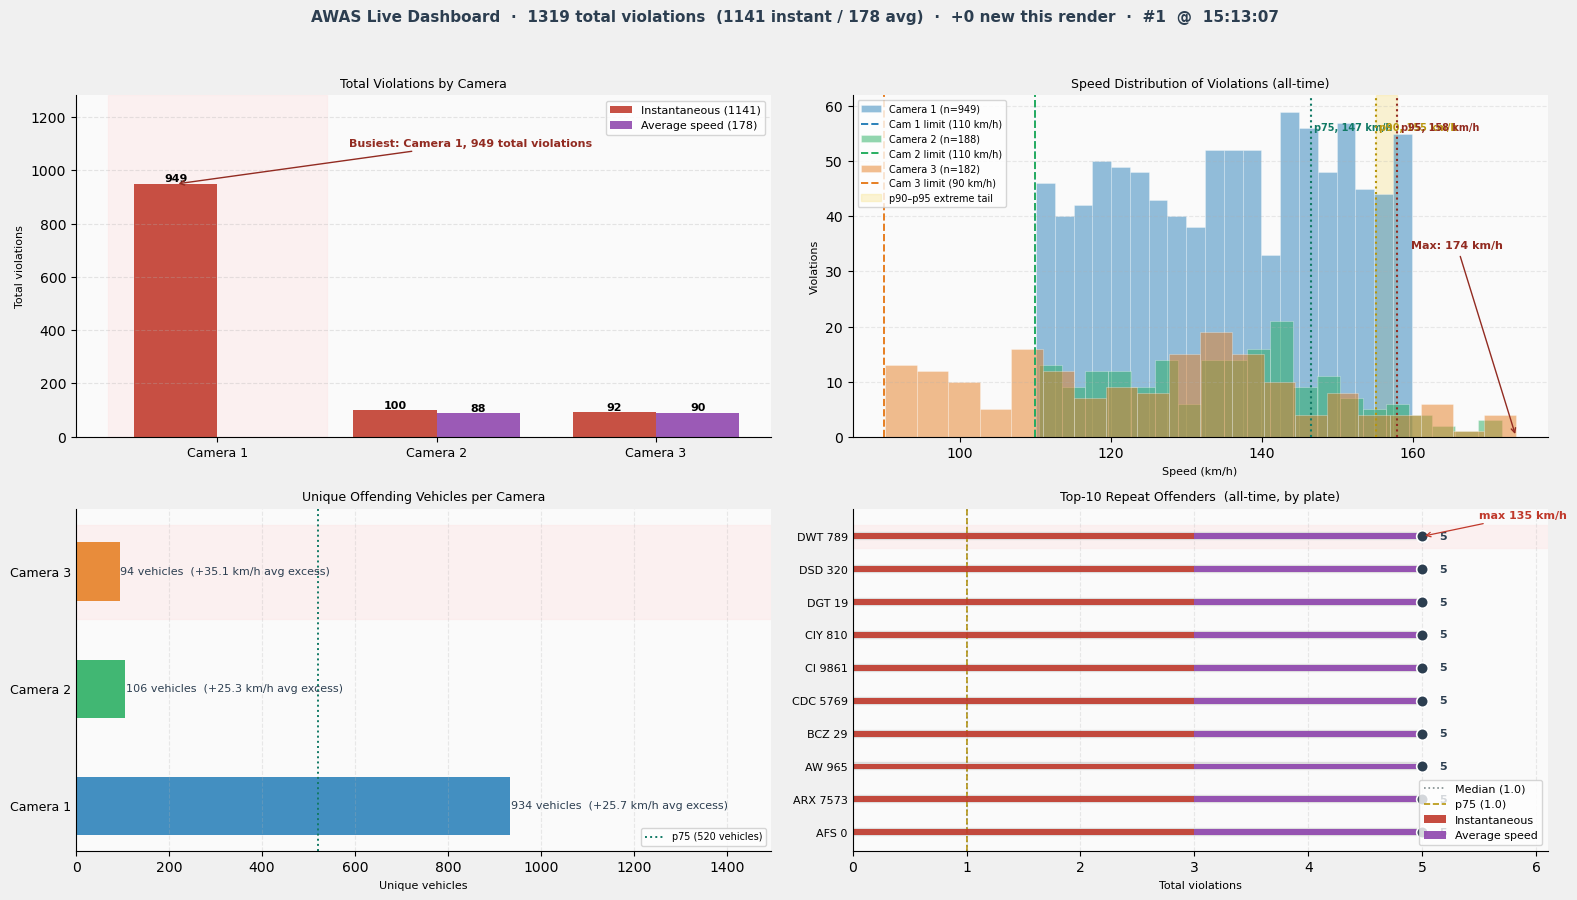

In [5]:
# Re-run this cell to refresh the dashboard.
print("Rendering dashboard")
render_dashboard()

In [6]:
%matplotlib notebook

import json
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from collections import deque
from pathlib import Path
from datetime import datetime

# ── File paths ────────────────────────────────────────────────────────────────
BASE_DIR = Path("..")

INSTANT_PATHS = {
    1: BASE_DIR / "outputs" / "instant_violations_json" / "camera_a" / "results.json",
    2: BASE_DIR / "outputs" / "instant_violations_json" / "camera_b" / "results.json",
    3: BASE_DIR / "outputs" / "instant_violations_json" / "camera_c" / "results.json",
}

AVG_PATHS = {
    "Segment A-B": BASE_DIR / "outputs" / "average_violations_json" / "camera_ab" / "results.json",
    "Segment B-C": BASE_DIR / "outputs" / "average_violations_json" / "camera_bc" / "results.json",
}

# ── Tuning knobs ──────────────────────────────────────────────────────────────
REFRESH_SECONDS    = 3    # polling interval
WINDOW_SIZE        = 200  # max raw events kept per deque
TIME_WINDOW_MINUTES = 90  # how many minutes of real time panels 1 & 2 show at once

# ── Colour palette ────────────────────────────────────────────────────────────
CAM_COLORS = {1: "#e74c3c", 2: "#2980b9", 3: "#27ae60"}
_CAB  = "#8e44ad"   # segment AB
_CBC  = "#d35400"   # segment BC

print("HD live visualisation config loaded.")

HD live visualisation config loaded.


In [7]:
# Deque state + incremental reader
#
# All persistent data lives in deques with maxlen=WINDOW_SIZE.
# Each poll only reads NEW lines from each file (tracked by _file_offsets),
# appends them to the right of the relevant deque, and lets the maxlen
# automatically evict the oldest entry from the left — the same sliding-
# window mechanic as the .pop(0) calls in Week10_Kafka_Consumer05.

#  Per-camera instant deques: (event_time, excess_speed) 
dq_cam = {
    cam_id: {"t": deque(maxlen=WINDOW_SIZE), "excess": deque(maxlen=WINDOW_SIZE)}
    for cam_id in [1, 2, 3]
}

#  Per-segment average-speed deques: (minute_bucket, count_in_that_minute) 
#  We store individual event times so we can re-bucket as the window shifts.
dq_avg = {
    seg: {"t": deque(maxlen=WINDOW_SIZE), "speed": deque(maxlen=WINDOW_SIZE)}
    for seg in ["AB", "BC"]
}

#  Combined rate deque: (minute_bucket, total_count) 
#  Keeps per-event timestamps; we bucket them each frame from the deque data.
dq_all_t = deque(maxlen=WINDOW_SIZE)   # event_time for every violation type

#  File-offset tracker so we only parse NEW lines each poll ─
_file_offsets = {}   # path_str -> byte offset


def _read_new_lines(path):
    """
    Return only lines added to *path* since the last call.

    Uses a byte-offset bookmark so the file is never re-read from the top.
    Returns an empty list if the file does not yet exist.
    """
    path = Path(path)
    if not path.exists():
        return []
    offset = _file_offsets.get(str(path), 0)
    new_rows = []
    with open(path, "r", encoding="utf-8") as fh:
        fh.seek(offset)
        for line in fh:
            stripped = line.strip()
            if stripped:
                try:
                    new_rows.append(json.loads(stripped))
                except json.JSONDecodeError:
                    pass
        _file_offsets[str(path)] = fh.tell()
    return new_rows


def poll_new_data():
    """
    Read any new records from all sink files and append them to the deques.

    This is called once per refresh cycle.  New points go on the RIGHT;
    the deque's maxlen automatically drops the oldest point from the LEFT,
    giving a smooth sliding-window effect.
    """
    #  Instantaneous violations 
    for cam_id, path in INSTANT_PATHS.items():
        for row in _read_new_lines(path):
            try:
                t   = pd.to_datetime(row["event_time"])
                spd = float(row["speed_recorded"])
                lim = float(row["speed_limit"])
                dq_cam[cam_id]["t"].append(t)
                dq_cam[cam_id]["excess"].append(round(spd - lim, 2))
                dq_all_t.append(t)
            except (KeyError, ValueError, TypeError):
                pass

    #  Average-speed violations 
    for seg, path in AVG_PATHS.items():
        for row in _read_new_lines(path):
            try:
                t   = pd.to_datetime(row["event_time"])
                spd = float(row["average_speed"])
                lim = float(row["speed_limit"])
                dq_avg[seg]["t"].append(t)
                dq_avg[seg]["speed"].append(spd)
                dq_all_t.append(t)
            except (KeyError, ValueError, TypeError):
                pass


def has_data():
    """Return True once at least one deque has accumulated enough points to plot."""
    cam_ready = any(len(dq_cam[c]["t"]) > 1 for c in [1, 2, 3])
    avg_ready = any(len(dq_avg[s]["t"]) > 1 for s in ["AB", "BC"])
    return cam_ready or avg_ready


print("Deque state and incremental reader defined.")

Deque state and incremental reader defined.


In [ ]:
# Panel drawing function, single panel: Live Violation Rate.
# Shades above the dynamic p90 level and annotates the peak minute
# with an arrow callout. p50 and p90 are dynamically labelled.

def draw_live_rate(ax):
    """
    Rolling violation rate per minute.

    Reads from: dq_all_t (all event timestamps).
    Only events within the last TIME_WINDOW_MINUTES are bucketed, so the
    x-axis always shows a fixed-width rolling window with no day-spanning gaps.
    Computes p50 and p90 dynamically from the current window.
    Shades the surge region above p90 and annotates the peak minute
    with an arrow callout.
    """
    ax.clear()
    ax.set_facecolor("#fafafa")
    ax.spines[["top", "right"]].set_visible(False)
    ax.tick_params(axis="both", labelsize=9)
    ax.set_title("Live Instant Violation Rate (violations / min)",
                 fontsize=11, fontweight="bold")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
    ax.tick_params(axis="x", rotation=30, labelsize=8)
    ax.grid(True, axis="y", alpha=0.2, linestyle="--")

    if len(dq_all_t) < 2:
        ax.text(0.5, 0.5, "Waiting for data…", ha="center", va="center",
                transform=ax.transAxes, color="#aaa", fontsize=12)
        ax.set_xlabel("Time", fontsize=9)
        ax.set_ylabel("Violations / min", fontsize=9)
        return

    # Apply the same rolling time window used by panels 1 & 2
    all_t = pd.Series(list(dq_all_t))
    t_max = all_t.max()
    t_min = t_max - pd.Timedelta(minutes=TIME_WINDOW_MINUTES)
    windowed = all_t[all_t >= t_min]

    if len(windowed) < 2:
        ax.text(0.5, 0.5, "Waiting for data…", ha="center", va="center",
                transform=ax.transAxes, color="#aaa", fontsize=12)
        ax.set_xlabel("Time", fontsize=9)
        ax.set_ylabel("Violations / min", fontsize=9)
        return

    by_min = windowed.dt.floor("min").value_counts().sort_index()

    times  = by_min.index
    values = by_min.values.astype(float)

    p50 = float(np.percentile(values, 50))
    p90 = float(np.percentile(values, 90))

    peak_idx    = int(np.argmax(values))
    peak_val    = values[peak_idx]
    peak_t      = times[peak_idx]
    has_callout = peak_val >= p90

    # Set y-axis limits before drawing so the callout fits inside─
    if has_callout:
        callout_top = peak_val + max(1.0, peak_val * 0.20)
        y_top = callout_top * 1.35
    else:
        y_top = peak_val * 1.25

    ax.set_ylim(bottom=0, top=y_top)
    ax.set_xlim(t_min, t_max)

    # Surge shading above p90─
    ax.fill_between(
        times, values, p90,
        where=(values >= p90),
        alpha=0.28, color="#e74c3c", interpolate=True,
        label=f"Surge (> p90={p90:.1f})",
    )

    # Main rate line
    ax.plot(times, values,
            color="#2c3e50", linewidth=2.0,
            marker="o", markersize=5, zorder=3,
            label="Violations / min")

    # p50 and p90 reference lines─
    ax.axhline(p50, color="#7f8c8d", linestyle=":", linewidth=1.2,
               label=f"Median (p50={p50:.1f})")
    ax.axhline(p90, color="#e74c3c", linestyle="--", linewidth=1.2,
               label=f"p90={p90:.1f}")

    # Peak callout
    if has_callout:
        offset = max(1.0, peak_val * 0.20)
        ax.annotate(
            f"Peak: {int(peak_val)} violations\n@ {peak_t.strftime('%H:%M')}",
            xy=(peak_t, peak_val),
            xytext=(peak_t, peak_val + offset),
            fontsize=8.5, color="#c0392b", fontweight="bold", ha="center",
            arrowprops=dict(arrowstyle="->", color="#c0392b", lw=1.2),
            bbox=dict(boxstyle="round,pad=0.3", fc="#fdf2f2",
                      ec="#c0392b", alpha=0.85),
        )

    ax.set_ylabel("Violations / min", fontsize=9)
    ax.set_xlabel("Time", fontsize=9)
    ax.legend(loc="upper left", fontsize=8.5, framealpha=0.75)


print("Panel drawing function defined.")

Panel drawing function defined.


<IPython.core.display.Javascript object>


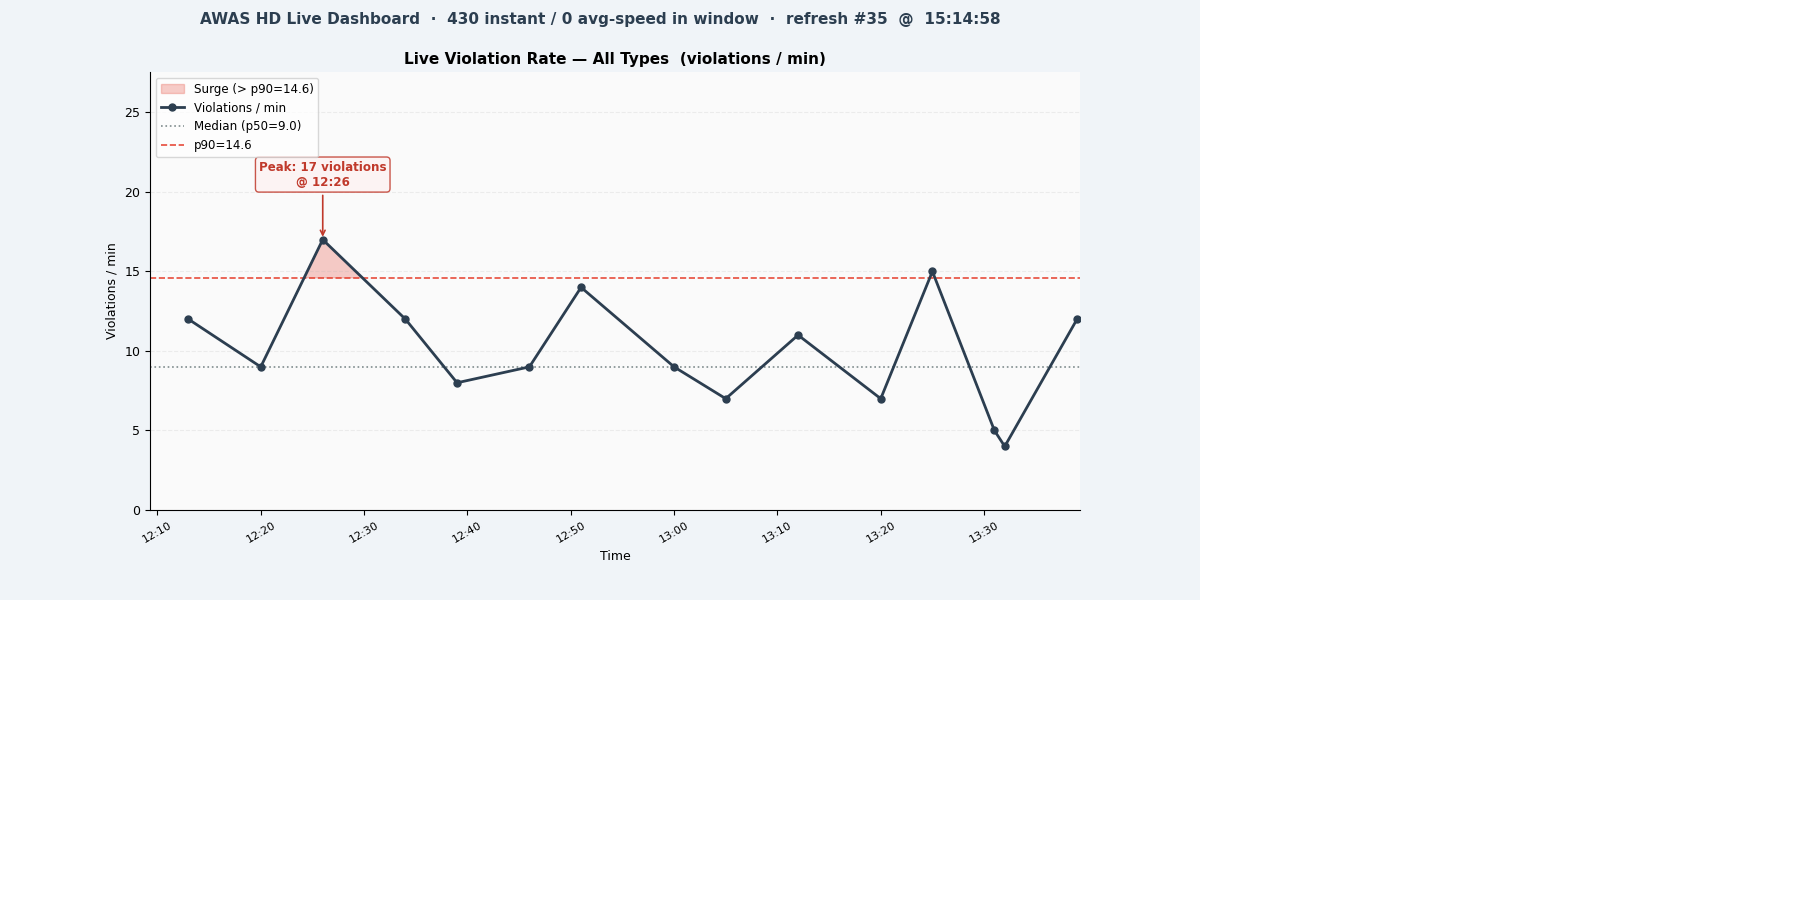

Live dashboard started — refreshing every 3s.
Interrupt the kernel (■) to stop.
[15:13:09]  Refresh #1  (392 instant / 0 avg-speed in window)
[15:13:12]  Refresh #2  (392 instant / 0 avg-speed in window)
[15:13:15]  Refresh #3  (394 instant / 0 avg-speed in window)
[15:13:18]  Refresh #4  (394 instant / 0 avg-speed in window)
[15:13:21]  Refresh #5  (397 instant / 0 avg-speed in window)
[15:13:25]  Refresh #6  (398 instant / 0 avg-speed in window)
[15:13:28]  Refresh #7  (400 instant / 0 avg-speed in window)
[15:13:31]  Refresh #8  (400 instant / 0 avg-speed in window)
[15:13:35]  Refresh #9  (400 instant / 0 avg-speed in window)
[15:13:38]  Refresh #10  (402 instant / 0 avg-speed in window)
[15:13:41]  Refresh #11  (405 instant / 0 avg-speed in window)
[15:13:44]  Refresh #12  (405 instant / 0 avg-speed in window)
[15:13:47]  Refresh #13  (405 instant / 0 avg-speed in window)
[15:13:51]  Refresh #14  (405 instant / 0 avg-speed in window)
[15:13:54]  Refresh #15  (405 instant / 0 avg-s

In [ ]:
# Live dashboard loop: single panel version.

def init_plot():
    """
    Create a single-panel figure and return (fig, ax).

    The figure is shown immediately so the widget appears before data arrives.
    """
    fig, ax = plt.subplots(figsize=(12, 6))
    fig.patch.set_facecolor("#f0f4f8")
    fig.subplots_adjust(top=0.88, bottom=0.15)
    fig.suptitle("AWAS HD Live Dashboard  ·  initialising…",
                 fontsize=12, fontweight="bold", color="#2c3e50")
    fig.show()
    fig.canvas.draw()
    return fig, ax


def consume_and_plot(fig, ax):
    """
    Main loop. Each iteration:
      - poll_new_data() appends fresh records to the deques
      - draw_live_rate() clears the axes and replots from the deque
      - fig.canvas.draw() flushes the update to the notebook widget
    """
    print(f"Live dashboard started: refreshing every {REFRESH_SECONDS}s.\n")

    poll = 0
    try:
        while True:
            poll_new_data()

            if has_data():
                poll += 1

                draw_live_rate(ax)

                total_inst = sum(len(dq_cam[c]["t"]) for c in [1, 2, 3])
                total_avg  = sum(len(dq_avg[s]["t"]) for s in ["AB", "BC"])
                fig.suptitle(
                    f"AWAS HD Live Dashboard  ·  "
                    f"{total_inst} instant"
                    f"·  refresh #{poll}  @  {datetime.now().strftime('%H:%M:%S')}",
                    fontsize=11, fontweight="bold", color="#2c3e50",
                )

                fig.canvas.draw()
                print(f"[{datetime.now().strftime('%H:%M:%S')}]  "
                      f"Refresh #{poll}  "
                      f"({total_inst} instant)")
            else:
                print(f"[{datetime.now().strftime('%H:%M:%S')}]  Waiting for data…")

            time.sleep(REFRESH_SECONDS)

    except KeyboardInterrupt:
        print("\nLive dashboard stopped.")
    finally:
        plt.close(fig)


fig, ax = init_plot()
consume_and_plot(fig, ax)